<a href="https://colab.research.google.com/github/purvabadhe/AI-in-Finance-/blob/main/Prewitts%20and%20Sobel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

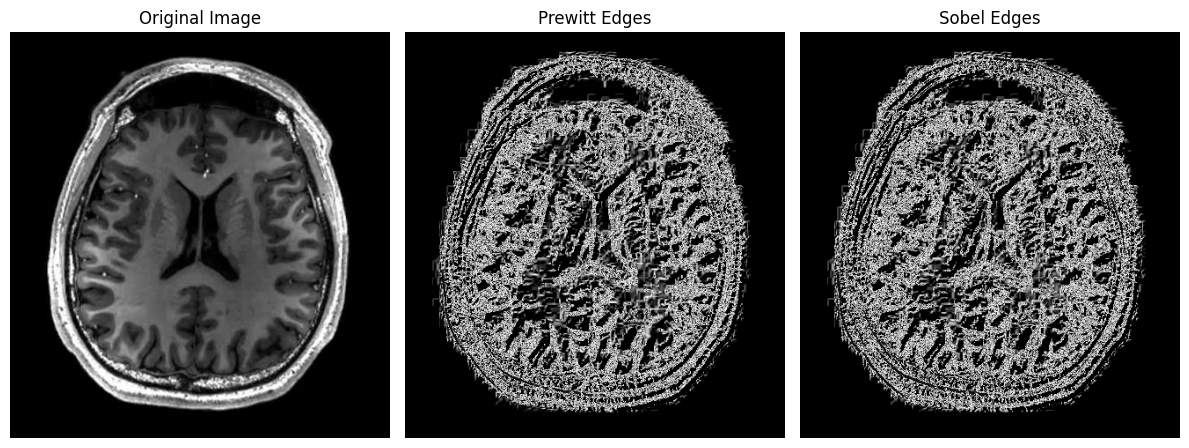

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

try:
    # Attempt to load a common test image
    img_path = '/content/MRI.jpeg' # Replace with your image path or a URL
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Warning: Image '{img_path}' not found. Creating a dummy image for demonstration.")
        # Create a simple dummy image for demonstration
        img = np.zeros((200, 200), dtype=np.uint8)
        img[50:150, 50:150] = 255 # A white square on a black background
        img = cv2.GaussianBlur(img, (5, 5), 0) # Add some blur for gradient detection
except Exception as e:
    print(f"Error loading image: {e}. Creating a dummy image.")
    img = np.zeros((200, 200), dtype=np.uint8)
    img[50:150, 50:150] = 255
    img = cv2.GaussianBlur(img, (5, 5), 0)

if img is None:
    print("Error: Could not load or create image. Exiting.")
else:
    # --- 2. Display the original image ---
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # --- 3. Apply Prewitt masks ---
    # Prewitt kernels
    kernel_x_prewitt = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    kernel_y_prewitt = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

    # Apply convolution
    grad_x_prewitt = cv2.filter2D(img, -1, kernel_x_prewitt)
    grad_y_prewitt = cv2.filter2D(img, -1, kernel_y_prewitt)

    # Magnitude of gradient
    prewitt_edges = np.sqrt(grad_x_prewitt**2 + grad_y_prewitt**2)
    prewitt_edges = cv2.normalize(prewitt_edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # --- 4. Display Prewitt results ---
    plt.subplot(1, 3, 2)
    plt.imshow(prewitt_edges, cmap='gray')
    plt.title('Prewitt Edges')
    plt.axis('off')

    # --- 5. Apply Sobel masks ---
    # Sobel kernels (OpenCV has a direct function for this)
    # grad_x_sobel = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    # grad_y_sobel = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Alternatively, defining kernels explicitly for clarity
    kernel_x_sobel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kernel_y_sobel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

    grad_x_sobel = cv2.filter2D(img, -1, kernel_x_sobel)
    grad_y_sobel = cv2.filter2D(img, -1, kernel_y_sobel)

    # Magnitude of gradient
    sobel_edges = np.sqrt(grad_x_sobel**2 + grad_y_sobel**2)
    sobel_edges = cv2.normalize(sobel_edges, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # --- 6. Display Sobel results ---
    plt.subplot(1, 3, 3)
    plt.imshow(sobel_edges, cmap='gray')
    plt.title('Sobel Edges')
    plt.axis('off')

    plt.tight_layout()
    plt.show()